In [1]:
%load_ext autoreload
%autoreload 2

In [30]:
import pickle
import jetsimpy
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from astropy.time import Time
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [3]:
from modules.tools import mag_to_flux, flux_to_mag
from modules.plotting_lc import plot_pseudo_obs
from modules.features import compute_duration_between_first_and_peak, compute_rates, compute_colours

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [5]:
all_orphans = pd.read_pickle('data/pseudo_obs_jetsimpy_5pts.pkl')

In [6]:
configs=[]

for lc in all_orphans:
    if lc != 0:
        configs.append(lc['config'])
    else:
        configs.append(np.nan)

## Duration between the first detection and the peak

In [7]:
dt = []

N = len(all_orphans)

for i in range(N):
    oa = all_orphans[i]
    
    if oa != 0:
        times = oa['time']
        mags = oa['mags']
        
        dt.append(compute_duration_between_first_and_peak(times, mags))

    else:
        dt.append(np.nan)

Text(0, 0.5, 'number of orphans')

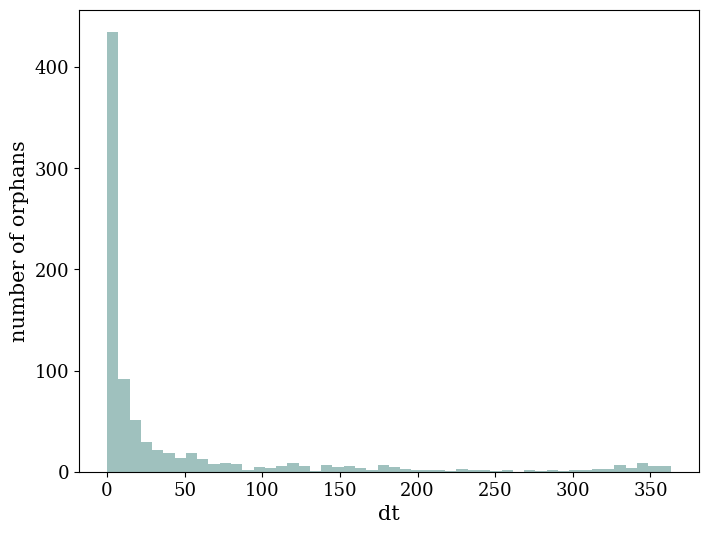

In [8]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8,6))

plt.hist(dt, bins=50, color='#41847f', alpha=0.5);
plt.xlabel('dt', fontsize=15)
plt.ylabel('number of orphans', fontsize=15)

## Increase and decrease rates

In [9]:
inc = []
dec1 = []
dec3 = []

N = len(all_orphans)

for i in range(N):
    oa = all_orphans[i]
    
    if oa != 0:
        times = oa['time']
        mags = oa['mags']
        filts = oa['filt']

        i, d1, d3 = compute_rates(times, mags, filts)

        inc.append(i)
        dec1.append(d1)
        dec3.append(d3)

    else:
        inc.append(np.nan)
        dec1.append(np.nan)
        dec3.append(np.nan)

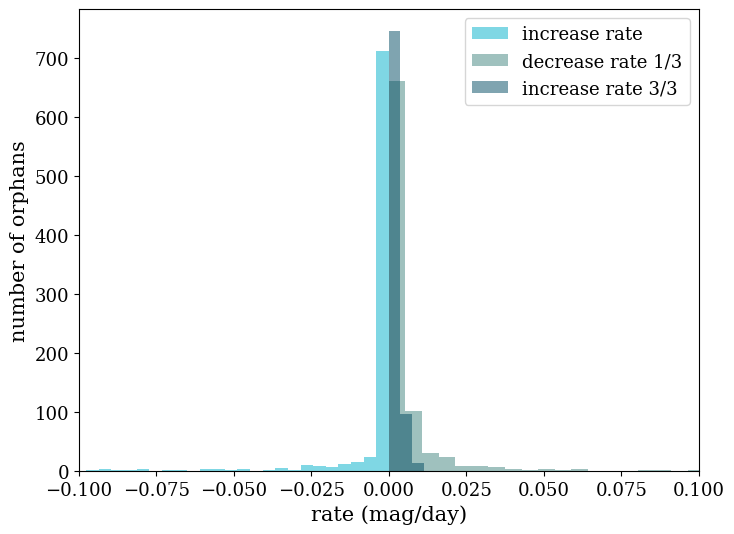

In [10]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8,6))

plt.hist(inc, bins=250, color='#00b1cb', alpha=0.5, label='increase rate');
plt.hist(dec1, bins=20, color='#41847f', alpha=0.5, label='decrease rate 1/3');
plt.hist(dec3, bins=3, color='#004b62', alpha=0.5, label='increase rate 3/3');

plt.xlabel('rate (mag/day)', fontsize=15)
plt.ylabel('number of orphans', fontsize=15)
plt.xlim(-0.1, 0.1)
plt.legend()

## Colours

In [11]:
filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'y': 'm'}
rev_filtercolors = {c:n for n, c in filtercolors.items()}
colours = []

N = len(all_orphans)

for i in range(N):
    oa = all_orphans[i]
    
    if oa != 0:
        times = oa['time']
        mags = oa['mags']
        filts = list(oa['filt'])

        filts_name = np.array([rev_filtercolors[f] for f in filts])

        c = compute_colours(times, mags, filts_name)

        colours.append(c)

    else:
        colours.append([np.nan, np.nan])

Mean g-r colour = 0.28841958272922363
Mean r-i colour = 0.1779920298222455


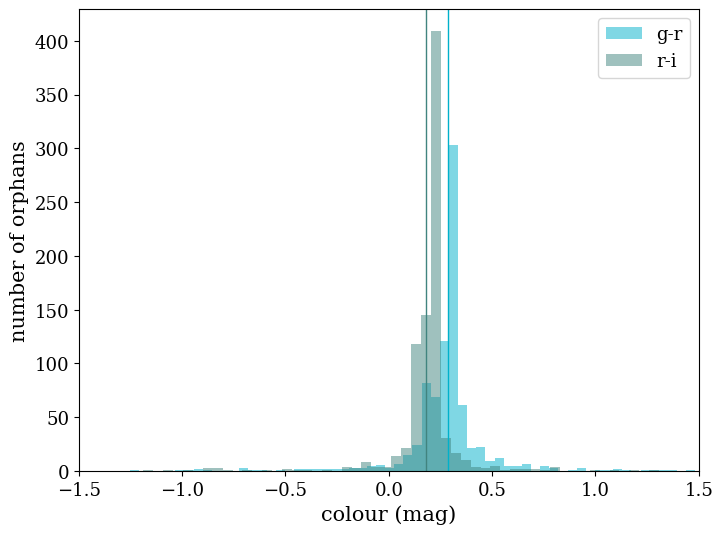

In [12]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8,6))

plt.hist(np.array(colours)[:,0], bins=300, color='#00b1cb', alpha=0.5, label='g-r');
plt.hist(np.array(colours)[:,1], bins=100, color='#41847f', alpha=0.5, label='r-i');

mean_gr = np.mean(np.array(colours)[:,0][~np.isnan(np.array(colours)[:,0])])
mean_ri = np.mean(np.array(colours)[:,1][~np.isnan(np.array(colours)[:,1])])

print(f'Mean g-r colour = {mean_gr}')
print(f'Mean r-i colour = {mean_ri}')

plt.axvline(x=mean_gr, color='#00b1cb', lw=1)
plt.axvline(x=mean_ri, color='#41847f', lw=1)

plt.xlabel('colour (mag)', fontsize=15)
plt.ylabel('number of orphans', fontsize=15)
plt.xlim(-1.5, 1.5)
plt.legend()

## Rescale a light curve

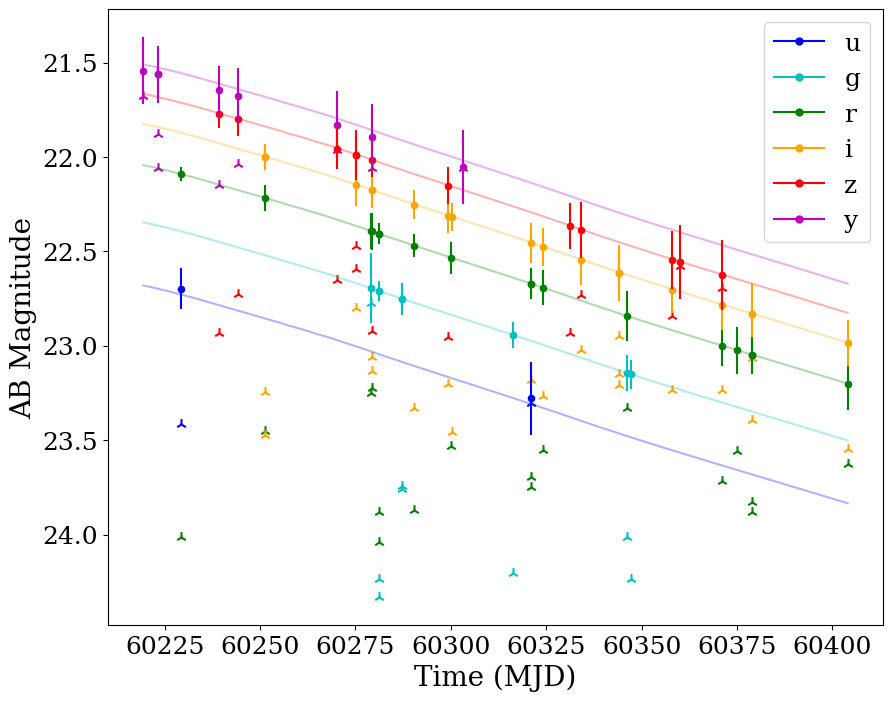

In [13]:
lc = all_orphans[7]
plot_pseudo_obs(lc)

In [14]:
# compute the flux of the considered light curve 
mags = np.array(lc['mags'])
mags_lim = np.array(lc['mags_lim'])
flux = mag_to_flux(mags)

# colors and mean frequency of the band u, g, r, i, z, y
colors = ['b', 'c', 'g', 'orange', 'r', 'm']
all_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 
          298760145396604.1]

all_mags = []
all_flux = []
all_time = []
all_err = []

# sort the magnitudes, flux, times and errors based on their filter
# times are computed in days after the first detection 
for f in colors:
    
    all_mags.append([lc['mags'][j] for j in range(len(lc['mags'])) 
                     if lc['mags'][j] < lc['mags_lim'][j] and lc['filt'][j]==f])
    
    all_flux.append([flux[j] for j in range(len(flux)) 
                     if lc['mags'][j] < lc['mags_lim'][j] and lc['filt'][j]==f])
    
    all_time.append([lc['time'][j]-min(lc['time']) for j in range(len(lc['mags'])) 
            if lc['mags'][j] < lc['mags_lim'][j] and lc['filt'][j]==f])
    
    all_err.append([lc['mags_err'][j] for j in range(len(lc['mags'])) 
            if lc['mags'][j] < lc['mags_lim'][j] and lc['filt'][j]==f])

# choose values of -beta between -(p-1)/2 and -p/2, with p=2.2
beta = np.linspace(-0.6, -1.1, 10)

# use the most populated band
len_flux = np.array([len(x) if x != all_flux[2] else 0 for x in all_flux])
more_flux = all_flux[np.where(len_flux == max(len_flux))[0][0]]
more_flux_time = all_time[np.where(len_flux == max(len_flux))[0][0]]
more_flux_nu = all_nu[np.where(len_flux == max(len_flux))[0][0]]

d = []

for b in beta:
    
    # compute the rescaled flux for each beta
    all_flux_one_r = np.array(more_flux) * (all_nu[2] / more_flux_nu)**(b)
    
    # compute the euclidean distance between the rescaled flux and the true r-band flux 
    d.append(np.sum(np.sqrt((np.array(more_flux_time)[:, np.newaxis] - np.array(all_time[2])[np.newaxis, :])**2 + 
                     (all_flux_one_r[:, np.newaxis] - np.array(all_flux[2])[np.newaxis, :])**2)))

all_flux_r = []

# for the beta that minimize the distance, rescale the flux for all the bands
for f, nu in zip(all_flux, all_nu):
    all_flux_r.append(np.array(f) * (all_nu[2] / nu)**(beta[np.where(d == min(d))])) 

# sorting them to create one array with all the times and one with all the fluxes
time = np.concatenate(all_time)
flux = np.concatenate(all_flux_r)
err = np.concatenate(all_err)
time_sorted = np.sort(time)
flux_sorted = np.array([f for _, f in sorted(zip(time, flux))])
mags_sorted = flux_to_mag(flux_sorted)

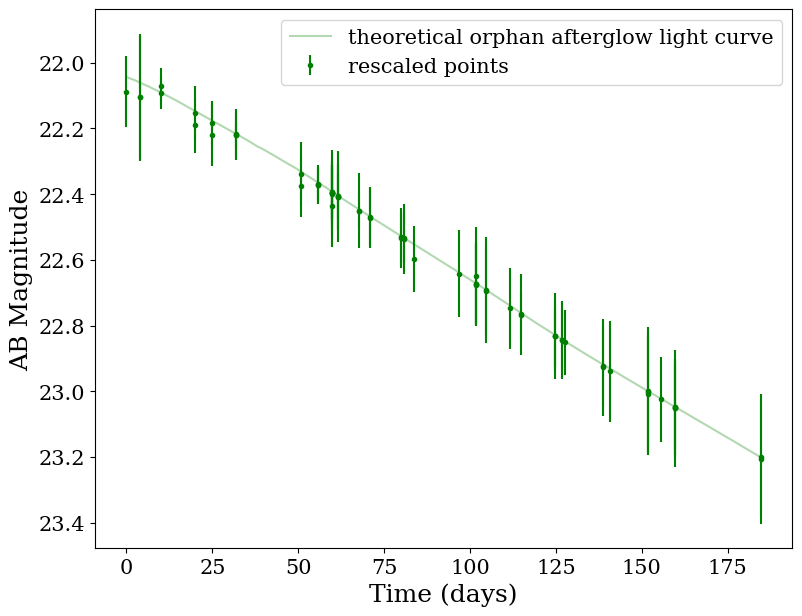

In [15]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(9, 7))

grb_time = Time(lc['grb_time']).mjd
P = lc['config']

t_min = min(np.array(lc['time'])[mags<mags_lim])-grb_time
t_max = max(np.array(lc['time'])[mags<mags_lim])-grb_time
t = np.geomspace(t_min, t_max, num=100)

nu = 482703137570394.2   # r-band frequency in Hz

jet = jetsimpy.Jet(
    jetsimpy.PowerLaw(P["theta_c"], P["Eiso"], lf0=P["lf"]),  # jet profile
    P["A"],  # wind number density scale
    P["n0"],  # ism number density scale
    spread=False,  # w/wo spreading effect
    grid=jetsimpy.ForwardJetRes(P["theta_c"], 129)  # resolution
)

flux = jet.FluxDensity(
    t*3600*24,  # [second] observing time span
    nu,  # [Hz]     observing frequency
    P,  # parameter dictionary
)

mag = flux_to_mag(flux)

plt.plot(t-min(t), mag, color='g', alpha=0.3, label='theoretical orphan afterglow light curve')
plt.errorbar(time_sorted, mags_sorted, yerr=err, marker='o', markersize=3, color='g', ls='', label='rescaled points')

plt.xlabel('Time (days)', fontsize=18)
plt.ylabel('AB Magnitude', fontsize=18)
plt.gca().invert_yaxis()
plt.legend()

## Fit

In [16]:
# data used for the fit
t = time_sorted
y = mags_sorted
yerr = err

def model(t, params):
    """Function used to fit the data points
    """
    
    A, B, C, D = params
    return A * t + B + C * np.exp(-D * t)


least_squares = LeastSquares(time_sorted, mags_sorted, err, model)

initial = np.array([0.02, 20., 0., 1.5])
m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

m.migrad()  # finds minimum of least_squares function
m.hesse()  # accurately computes uncertainties

A = m.values[0]
B = m.values[1]
C = m.values[2]
D = m.values[3]
chi2 = m.fmin.reduced_chi2

Best parameters are: A=0.01, B=22.02, C=0.07, D=8.06


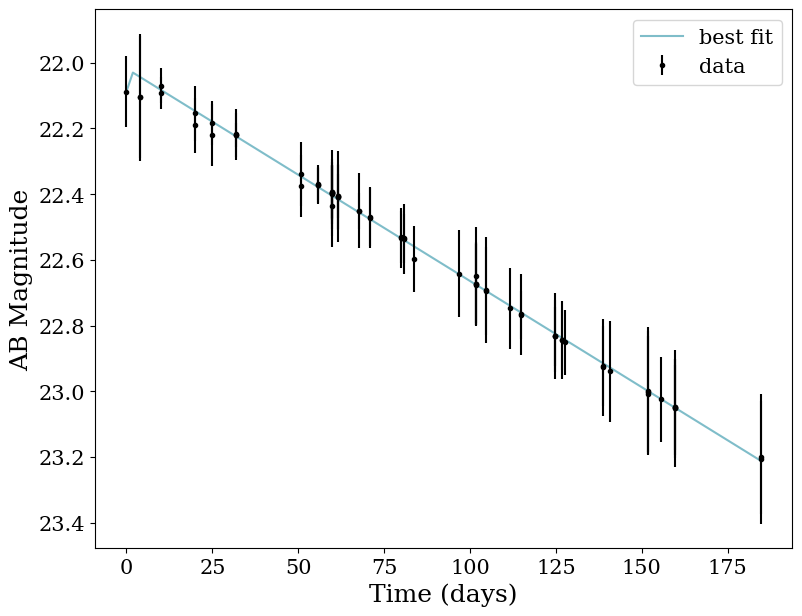

In [17]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(9, 7))

# time used to compute fitted model
t_min = min(time_sorted)
t_max = max(time_sorted)
t_fit = np.linspace(t_min, t_max, num=100)

fit = model(t_fit, m.values)

print('Best parameters are: A=%.2f, B=%.2f, C=%.2f, D=%.2f' %(m.values[0], m.values[1], m.values[2], m.values[3]))
    
plt.plot(t_fit, fit, color='#007c95', label='best fit', alpha=0.5)
plt.errorbar(time_sorted, mags_sorted, yerr=err, marker='o', ls='', markersize=3, color='k', label='data')

plt.xlabel('Time (days)', fontsize=18)
plt.ylabel('AB Magnitude', fontsize=18)
plt.gca().invert_yaxis()

plt.legend()

plt.show()

### Test on several light curves

In [18]:
# define functions

def rescale(lc):
    # compute the flux of the considered light curve 
    mags = np.array(lc['mags'])
    mags_lim = np.array(lc['mags_lim'])
    flux = mag_to_flux(mags)
    
    # colors and mean frequency of the band u, g, r, i, z, y
    colors = ['b', 'c', 'g', 'orange', 'r', 'm']
    all_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 
              298760145396604.1]
    
    all_mags = []
    all_flux = []
    all_time = []
    all_err = []
    
    # sort the magnitudes, flux, times and errors based on their filter
    # times are computed in days after the first detection 
    for f in colors:
        
        all_mags.append([lc['mags'][j] for j in range(len(lc['mags'])) 
                         if lc['mags'][j] < lc['mags_lim'][j] and lc['filt'][j]==f])
        
        all_flux.append([flux[j] for j in range(len(flux)) 
                         if lc['mags'][j] < lc['mags_lim'][j] and lc['filt'][j]==f])
        
        all_time.append([lc['time'][j]-min(lc['time']) for j in range(len(lc['mags'])) 
                if lc['mags'][j] < lc['mags_lim'][j] and lc['filt'][j]==f])
        
        all_err.append([lc['mags_err'][j] for j in range(len(lc['mags'])) 
                if lc['mags'][j] < lc['mags_lim'][j] and lc['filt'][j]==f])
    
    # choose values of -beta between -(p-1)/2 and -p/2, with p=2.2
    beta = np.linspace(-0.6, -1.1, 10)
    
    # use the most populated band
    len_flux = np.array([len(x) if x != all_flux[2] else 0 for x in all_flux])
    more_flux = all_flux[np.where(len_flux == max(len_flux))[0][0]]
    more_flux_time = all_time[np.where(len_flux == max(len_flux))[0][0]]
    more_flux_nu = all_nu[np.where(len_flux == max(len_flux))[0][0]]
    
    d = []
    
    for b in beta:
        
        # compute the rescaled flux for each beta
        all_flux_one_r = np.array(more_flux) * (all_nu[2] / more_flux_nu)**(b)
        
        # compute the euclidean distance between the rescaled flux and the true r-band flux 
        d.append(np.sum(np.sqrt((np.array(more_flux_time)[:, np.newaxis] - np.array(all_time[2])[np.newaxis, :])**2 + 
                         (all_flux_one_r[:, np.newaxis] - np.array(all_flux[2])[np.newaxis, :])**2)))
    
    all_flux_r = []
    
    # for the beta that minimize the distance, rescale the flux for all the bands
    for f, nu in zip(all_flux, all_nu):
        all_flux_r.append(np.array(f) * (all_nu[2] / nu)**(beta[np.where(d == min(d))][0])) 
    
    # sorting them to create one array with all the times and one with all the fluxes
    time = np.concatenate(all_time)
    flux = np.concatenate(all_flux_r)
    err = np.concatenate(all_err)
    time_sorted = np.sort(time)
    flux_sorted = np.array([f for _, f in sorted(zip(time, flux))])
    mags_sorted = flux_to_mag(flux_sorted)

    return time_sorted, mags_sorted, err


def model(t, params):
    """Function used to fit the data points
    """
    
    A, B, C, D = params
    return A * t + B + C * np.exp(-D * t)


def perform_fit(time_sorted, mags_sorted, err):

    # data used for the fit
    t = time_sorted
    y = mags_sorted
    yerr = err 

    least_squares = LeastSquares(time_sorted, mags_sorted, err, model)
    
    initial = np.array([0.02, 20., 0., 1.5])
    m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))
    
    m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]
    
    m.migrad()  # finds minimum of least_squares function
    m.hesse()  # accurately computes uncertainties

    return m.values, m.fmin.reduced_chi2

In [19]:
fit_params = []
fit_chi2 = []

for lc in all_orphans:

    if lc != 0:

        time_sorted, mags_sorted, err = rescale(lc)
        params, chi2 = perform_fit(time_sorted, mags_sorted, err)

        fit_params.append([params[0], params[1], params[2], params[3]])
        fit_chi2.append(chi2)

    else:
        fit_params.append([np.nan, np.nan, np.nan, np.nan])
        fit_chi2.append(np.nan)
        continue

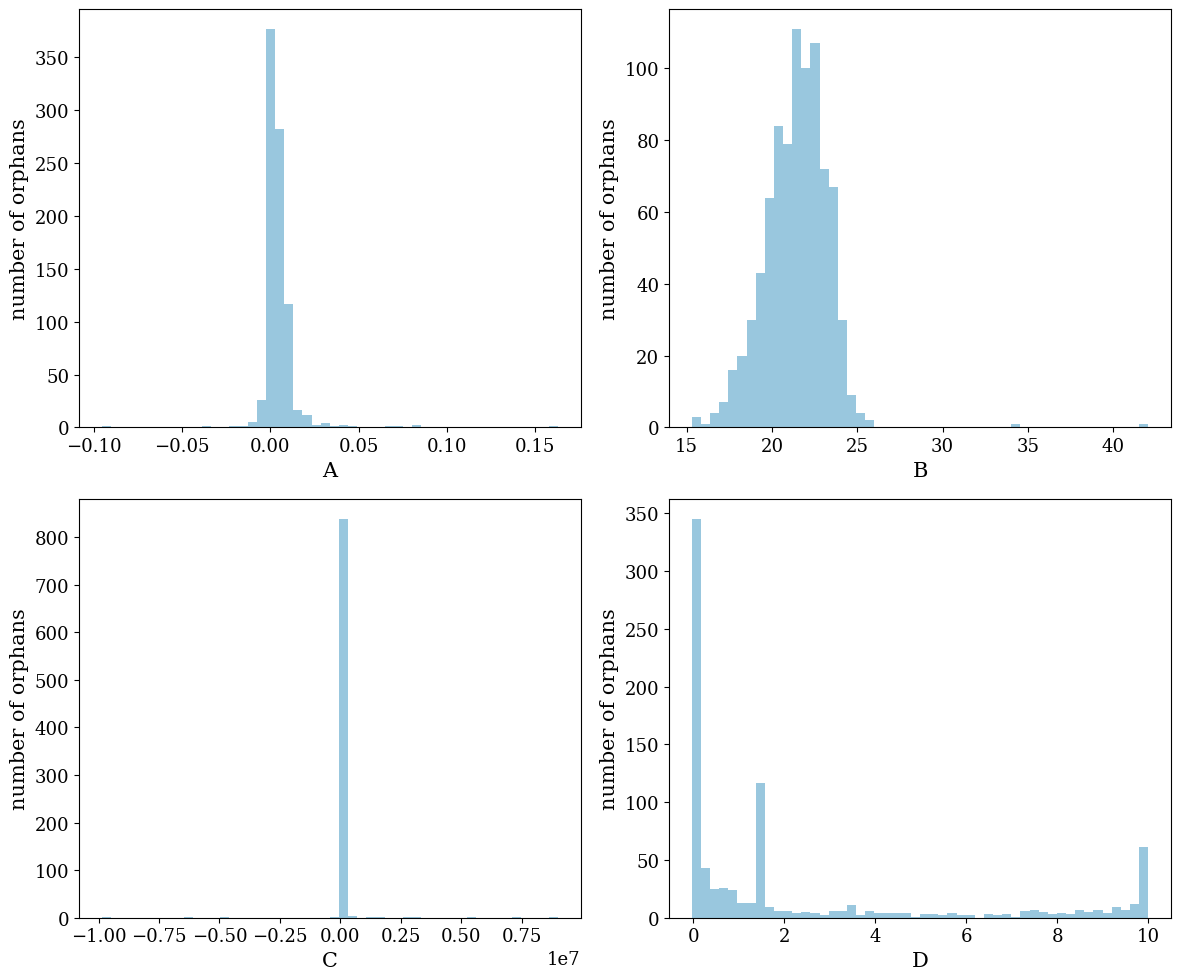

In [20]:
labels = ['A', 'B', 'C', 'D']

plt.rcParams.update({'font.size': 13})
fig, axes = plt.subplots(figsize=(12,10), nrows=2, ncols=2)

axes = axes.flatten()

for i in range(4):
    axes[i].hist(np.array(fit_params)[:, i], bins=50, color='#0075ad', alpha=0.4)
    axes[i].set_ylabel('number of orphans', fontsize=15)
    axes[i].set_xlabel(labels[i], fontsize=15)

plt.tight_layout()
plt.show()

## Gather all the data in a dataframe

In [27]:
dict_features = {'duration': dt, 
                 'increase_rate': inc,
                 'decrease_rate_1': dec1,
                 'decrease_rate_3': dec3,
                 'g-r': np.array(colours)[:,0],
                 'r-i': np.array(colours)[:,1],
                 'A': np.array(fit_params)[:, 0],
                 'B': np.array(fit_params)[:, 1],
                 'C': np.array(fit_params)[:, 2],
                 'D': np.array(fit_params)[:, 3],
                 'chi2': fit_chi2
                }

df_features = pd.DataFrame(data=dict_features)
df_features['A_over_B'] = df_features['A']/df_features['B']

In [28]:
df_features

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,r-i,A,B,C,D,chi2,A_over_B
0,0.024818,-0.000071,0.000000,0.000000,0.313041,0.220544,-0.000631,22.711497,0.000000e+00,1.500000,0.000769,-0.000028
1,22.993968,0.000000,0.004395,0.005313,0.324262,0.225401,0.006726,21.440344,1.893980e-01,9.971463,0.328047,0.000314
2,0.000000,0.000000,0.044859,0.008399,0.339790,0.221749,0.011037,18.627513,-1.486090e+00,0.071682,19.895499,0.000593
3,0.000000,0.000000,0.004049,0.003055,0.354543,0.220726,0.005759,23.494464,-9.875024e+06,2.459225,0.002470,0.000245
4,0.024389,0.000000,0.014704,0.005715,0.086626,0.226944,0.018715,23.924150,-1.923224e+00,0.018961,0.120004,0.000782
...,...,...,...,...,...,...,...,...,...,...,...,...
858,0.024676,0.000000,0.000000,0.000000,NaN,0.355614,0.002832,21.291069,-6.260444e-01,0.174980,0.367418,0.000133
859,0.000000,-0.000012,0.000143,0.000009,0.323763,0.228790,0.000837,22.034317,5.817080e-01,0.000014,0.040441,0.000038
860,66.807467,-0.010072,0.000000,0.000000,-0.090246,0.161956,0.001062,22.367079,0.000000e+00,1.500000,0.220699,0.000047
861,79.882320,-0.057222,0.000218,0.000053,0.166574,0.188840,0.000491,23.848732,0.000000e+00,1.500000,0.102309,0.000021


In [29]:
df_features.to_csv('/home/masson/jetsimpy/orphan_pop/data/features_jetsimpy.txt', sep='\t', index=False)